<a href="https://colab.research.google.com/github/tetianashlemko/Online-Store-Sales-Analytics-SQL-Python-Tableau/blob/main/Online_Store_Sales_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Завантаження та огляд даних**

In [ ]:
# встановлення бібліотеки для роботи з Google BigQuery

!pip install --upgrade google-cloud-bigquery


In [ ]:
# Імпортую модулі для аутентифікації та роботи з BigQuery, а також бібліотеку pandas для обробки результатів запиту
from google.colab import auth
from google.cloud import bigquery
import pandas as pd

# команда для аутентифікації
auth.authenticate_user()

# створення клієнта для роботи з BigQuery
client = bigquery.Client(project="data-analytics-mate")


In [ ]:
# SQL запит
query = """
WITH
  sessions AS (
  SELECT
    s.date,
    s.ga_session_id,
    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name,
    sp.operating_system,
    sp.language AS browser_language,
    sp.name AS traffic_source,
    sp.channel
  FROM
    `DA.session` s
  JOIN
    `DA.session_params` sp
  ON
    s.ga_session_id = sp.ga_session_id ),

  accounts AS (
  SELECT
    acs.ga_session_id,
    acs.account_id,
    ac.is_verified,
    ac.is_unsubscribed
  FROM
    `DA.account_session` acs
  LEFT JOIN
    `DA.account` ac
  ON
    acs.account_id = ac.id ),

  orders AS (
  SELECT
    o.ga_session_id,
    p.category AS product_category,
    p.name AS product_name,
    p.price,
    p.short_description
  FROM
    `DA.order` o
  LEFT JOIN
    `DA.product` p
  ON
    o.item_id = p.item_id )

SELECT
  se.date,
  se.ga_session_id,
  se.continent,
  se.country,
  se.device,
  se.browser,
  se.mobile_model_name,
  se.operating_system,
  se.browser_language,
  se.traffic_source,
  se.channel,
  a.account_id,
  a.is_verified,
  a.is_unsubscribed,
  os.product_category,
  os.product_name,
  os.price,
  os.short_description
FROM
  sessions se
LEFT JOIN
  accounts a
ON
  se.ga_session_id = a.ga_session_id
LEFT JOIN
  orders os
ON
  se.ga_session_id = os.ga_session_id
"""


In [ ]:
query_job = client.query(query)  # Виконання SQL-запиту
results = query_job.result()  # Очікування завершення запиту


In [ ]:
df = results.to_dataframe()


In [ ]:
df.head()


,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,browser_language,traffic_source,channel,account_id,is_verified,is_unsubscribed,product_category,product_name,price,short_description
0,2021-01-19,7268004754,(not set),(not set),desktop,Chrome,Chrome,Web,en-gb,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None
1,2021-01-06,8321293308,(not set),(not set),desktop,Chrome,Chrome,Web,None,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None
2,2020-11-05,4392362373,(not set),(not set),desktop,Chrome,Chrome,Web,None,(organic),Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None
3,2020-12-09,140108698,(not set),(not set),desktop,Chrome,Safari,Web,en-us,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None
4,2020-11-10,8351127264,(not set),(not set),mobile,Safari,iPhone,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   browser_language   235279 non-null  object 
 9   traffic_source     349545 non-null  object 
 10  channel            349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  product_category   33538 non-null   object 
 15  product_name       33538 non-null   object 
 16  pr

In [ ]:
# змінюю формат стовпчика "date" на datetime64[ns]
df["date"] = pd.to_datetime(df["date"])

In [ ]:
# аналізую період часу в датасеті
print(f'Період часу який охоплений в датасеті: з {df["date"].min()} до {df["date"].max()}')

Період часу який охоплений в датасеті: з 2020-11-01 00:00:00 до 2021-01-31 00:00:00


In [ ]:
print(f"Кількість унікальних сесій: {df['ga_session_id'].count()}")

Кількість унікальних сесій: 349545


In [ ]:
#  аналізую кількіть пропущених значень у кожній колонці
df.isna().sum()

,0
date,0
ga_session_id,0
continent,0
country,0
device,0
browser,0
mobile_model_name,0
operating_system,0
browser_language,114266
traffic_source,0


In [ ]:
#  відсутні значення в стовпчику browser_language заповнюю "(not set)"
df["browser_language"] = df["browser_language"].fillna("(not set)")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   date               349545 non-null  datetime64[ns]
 1   ga_session_id      349545 non-null  Int64         
 2   continent          349545 non-null  object        
 3   country            349545 non-null  object        
 4   device             349545 non-null  object        
 5   browser            349545 non-null  object        
 6   mobile_model_name  349545 non-null  object        
 7   operating_system   349545 non-null  object        
 8   browser_language   349545 non-null  object        
 9   traffic_source     349545 non-null  object        
 10  channel            349545 non-null  object        
 11  account_id         27945 non-null   Int64         
 12  is_verified        27945 non-null   Int64         
 13  is_unsubscribed    27945 non-null   Int64   

**Опис датасету:**  
Датасет містить дані про користувацькі сесії, зокрема дату, географічне розташування, тип пристрою, браузер, джерело трафіку, а також (за наявності) інформацію про акаунт і покупки, такі як категорія товару, назва, ціна та опис.


---



*date* - дата сесії  
*ga_session_id* - ідентифікатор сесії  
*continent* - континент (наприклад: Americas, Asia, Europe та інші)   
*country* - країна  (United States, India, Canada та інші)  
*device* - девайс (desktop, mobile, tablet)   
*browser* - браузер (Chrome, Safari, Edge та інші)   
*mobile_model_name* - назва моделі пристрою  (Chrome, iPhone, Safari та інші)  
*operating_system* - операційна система  (Web, Windows, iOS та інші)  
*browser_language* - мова браузера  (en-us, en-gb та інші)  
*traffic_source* - інформація про джерело трафіку   (organic, direct та інші)  
*channel* - канал трафіку  (Organic Search, Paid Search, Direct та інші)  
*account_id* - ідентифікатор зареєстрованого користувача  
*is_verified* - чи підтвердив користувач свій email (1-підтвердив, 0-не підтвердив)   
*is_unsubscribed* - чи відписався користувач від розсилки (1-відписався, 0-не відписався)   
*product_category* - категорія товару (Chairs, Sofas & armchairs та інші)   
*product_name* - назва товару  (BESTÅ, GRÖNLID, TROFAST та інші)
*price* - ціна  
*short_description* - короткий опис товару  


---



Загальна кількість колонок: 18  
в т.ч.  
 1 числова (price)  
 1 типу datetime (date)  
13 категоріальних (continent, country, device, browser, mobile_model_name,  operating_system, browser_language, traffic_source, channel, is_verified,   is_unsubscribed, product_category, product_name)  

Всього **349545** записів

Кількість унікальних сесій: **349545**

Період часу який охоплений в датасеті: з **2020-11-01** до **2021-01-31**


---



У колонках account_id, is_verified, is_unsubscribed, product_category, product_name, price та short_description міститься багато відсутніх значень. Це можна пояснити тим, що в датасеті представлено **усі сесії**, включно з тими, під час яких не було створено акаунт або не здійснено покупку. Відповідно, у стовпцях, які стосуються акаунтів і покупок, відсутні дані.



#**Аналіз та візуалізація даних**

## Огляд сесій

In [ ]:
df.head()

,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,browser_language,traffic_source,channel,account_id,is_verified,is_unsubscribed,product_category,product_name,price,short_description
0,2021-01-19,7268004754,(not set),(not set),desktop,Chrome,Chrome,Web,en-gb,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None
1,2021-01-06,8321293308,(not set),(not set),desktop,Chrome,Chrome,Web,(not set),(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None
2,2020-11-05,4392362373,(not set),(not set),desktop,Chrome,Chrome,Web,(not set),(organic),Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None
3,2020-12-09,140108698,(not set),(not set),desktop,Chrome,Safari,Web,en-us,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None
4,2020-11-10,8351127264,(not set),(not set),mobile,Safari,iPhone,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None


In [ ]:
# загальна кількість сесій
print(f'Загальна кількість сесій: {df["ga_session_id"].count()}')

Загальна кількість сесій: 349545


In [ ]:
# відсоток сесій з продажами
print(f'Кількість сесій з продажами: {df["product_name"].count()}')
percent_order = (df["product_name"].count() / df["ga_session_id"].count()) * 100
print(f'Відсоток сесій з продажами: {percent_order:.2f}%')

Кількість сесій з продажами: 33538
Відсоток сесій з продажами: 9.59%


In [ ]:
# відсоток сесій з акаунтами(зареєстровані користувачі))
print(f'Кількість сесій з акаунтами: {df["account_id"].count()}')
percent_acc = (df["account_id"].count() / df["ga_session_id"].count()) * 100
print(f'Відсоток сесій з акаунтами: {percent_acc:.2f}%')

Кількість сесій з акаунтами: 27945
Відсоток сесій з акаунтами: 7.99%


In [ ]:
# топ 5 країн по кількості зареєстрованих користувачів
grouped_by_country = df.groupby("country")["account_id"].count()
print(grouped_by_country.sort_values(ascending= False).head(5))

country
United States     12384
India              2687
Canada             2067
United Kingdom      859
France              553
Name: account_id, dtype: Int64


In [ ]:
# який відсоток зареєстрованих користувачів підтвердили свою електронну адресу
acc_is_verified = df[df["is_verified"] == 1]
percent_acc_is_verified = (acc_is_verified["account_id"].count() / df["account_id"].count()) * 100
print(f'Відсоток зареєстрованих користувачів які підтвердили свою електронну адресу: {percent_acc_is_verified:.2f}%')

Відсоток зареєстрованих користувачів які підтвердили свою електронну адресу: 71.70%


In [ ]:
# який відсоток зареєстрованих користувачів відписались від розсилки
acc_is_unsubscribed = df[df["is_unsubscribed"] == 1]
percent_acc_is_unsubscribed = (acc_is_unsubscribed["account_id"].count() / df["account_id"].count()) * 100
print(f'Відсоток зареєстрованих користувачів які відписались від розсилки: {percent_acc_is_unsubscribed:.2f}%')

Відсоток зареєстрованих користувачів які відписались від розсилки: 16.94%


## Аналіз сесій з продажами

In [ ]:
# загальна сума продажу за весь період
total_price = df["price"].sum()
print(f'Загальна сума продажу за весь період: {total_price:,.0f}$')

Загальна сума продажу за весь період: 31,971,731$


In [ ]:
# топ-3 континента з найбільшими продажами
grouped_by_continent_order = df.groupby("continent")["price"].sum().sort_values(ascending= False).head(3)
print(grouped_by_continent_order.apply(lambda x: f"{x:,.0f}$"))


continent
Americas    17,665,280$
Asia         7,601,298$
Europe       5,934,624$
Name: price, dtype: object


In [ ]:
# топ-5 країн з найбільшими продажами
grouped_by_country_order = df.groupby("country")["price"].sum().sort_values(ascending= False).head(5)
print(grouped_by_country_order.apply(lambda x: f"{x:,.0f}$"))

country
United States     13,943,554$
India              2,809,762$
Canada             2,437,921$
United Kingdom       938,318$
France               710,693$
Name: price, dtype: object


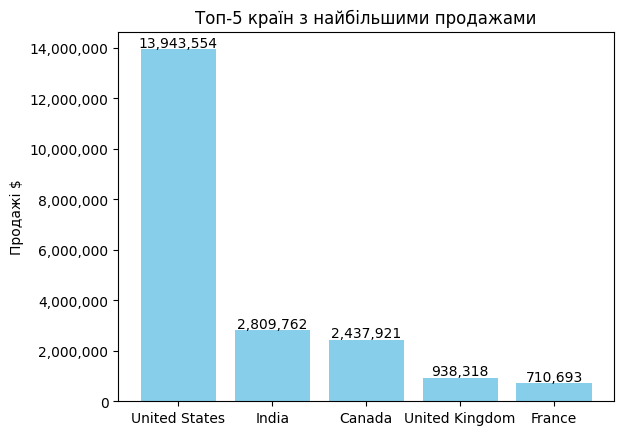

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


plt.bar(grouped_by_country_order.index, grouped_by_country_order.values , color="skyblue")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

#додавання форматованих підписів над стовпцями
for i, value in enumerate(grouped_by_country_order.values):
     plt.text(i, value +100000,   f"{value:,.0f}",  fontsize=10, ha='center')

plt.title("Tоп-5 країн з найбільшими продажами")  # Title of the graph
# plt.xlabel("")  # X-axis label
plt.ylabel("Продажі $")  # Y-axis label
plt.show()

In [ ]:
# топ-5 країн з найбільшими продажами з % від тотал
percent_by_country = ((grouped_by_country_order / total_price) * 100).round(2)

summary_by_country = pd.DataFrame({
    "Sales $": grouped_by_country_order.apply(lambda x: f"{x:,.0f}"),
    "% from total": percent_by_country
})
print(summary_by_country)

                   Sales $  % from total
country                                 
United States   13,943,554         43.61
India            2,809,762          8.79
Canada           2,437,921          7.63
United Kingdom     938,318          2.93
France             710,693          2.22


In [ ]:
# топ-10 найпопулярніших категорій
grouped_by_category_order_cnt = df.groupby("product_category")["product_name"].count().sort_values(ascending= False).head(10)
print(grouped_by_category_order_cnt)

product_category
Bookcases & shelving units          7630
Chairs                              5952
Sofas & armchairs                   4301
Tables & desks                      2941
Beds                                2926
Cabinets & cupboards                2318
Outdoor furniture                   2229
Children's furniture                1702
Chests of drawers & drawer units    1452
Bar furniture                       1092
Name: product_name, dtype: int64


In [ ]:
# топ-10 категорій за сумою продажів
grouped_by_category_order = df.groupby("product_category")["price"].sum().sort_values(ascending= False).head(5)
print(grouped_by_category_order.apply(lambda x: f"{x:,.0f}$"))

product_category
Sofas & armchairs             8,388,254$
Chairs                        6,147,749$
Beds                          4,919,725$
Bookcases & shelving units    3,640,818$
Cabinets & cupboards          2,336,500$
Name: price, dtype: object


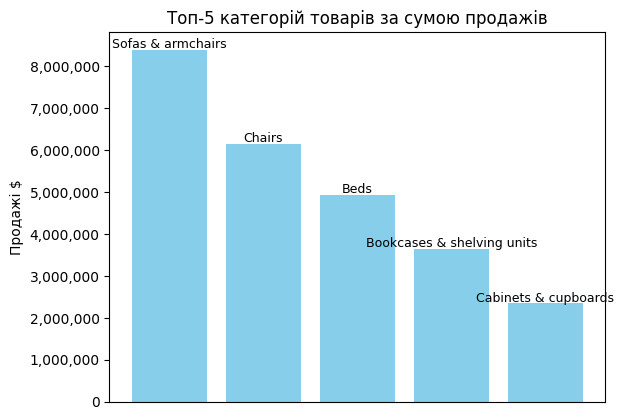

In [ ]:

plt.bar(grouped_by_category_order.index, grouped_by_category_order.values , color="skyblue")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# #додавання форматованих підписів над стовпцями
# for i, value in enumerate(grouped_by_category_order.values):
#      plt.text(i, value +100000,   f"{value:,.0f}",  fontsize=10, ha='center')
for i, (category, value) in enumerate(zip(grouped_by_category_order.index, grouped_by_category_order.values)):
    plt.text(i, value + 50000,  category, ha='center', rotation=0, fontsize=9, color='black')

# plt.xticks(rotation=90, fontsize=9)
plt.xticks([])
plt.title("Топ-5 категорій товарів за сумою продажів")  # Title of the graph
# plt.xlabel("Country")  # X-axis label
plt.ylabel("Продажі $")  # Y-axis label
plt.show()

In [ ]:
# топ-10 категорій у країні з найбільшими продажами
top_country_order = df.groupby("country")["price"].sum().sort_values(ascending= False).head(1)
top_country = top_country_order.index[0]
print(f'Країна з найбільшими продажами: {top_country}')

df_top_country = df[df["country"] == top_country]

top_category_vs_top_country = df_top_country.groupby("product_category")["price"].sum().sort_values(ascending= False).head(10)
print(top_category_vs_top_country.apply(lambda x: f"{x:,.0f}$"))

Країна з найбільшими продажами: United States
product_category
Sofas & armchairs                   3,707,144$
Chairs                              2,619,774$
Beds                                2,213,058$
Bookcases & shelving units          1,567,607$
Cabinets & cupboards                  994,546$
Outdoor furniture                     929,245$
Tables & desks                        777,865$
Chests of drawers & drawer units      382,388$
Bar furniture                         330,805$
Children's furniture                  207,575$
Name: price, dtype: object


Топ-10 категорій по всіх караїнах збігається з топ-10 категорій товарів у країні з найбільшими продажами.

In [ ]:
#  аналізую продажі в розрізі device
order_by_device = df.groupby("device")["price"].sum().sort_values(ascending= False)
print(order_by_device.apply(lambda x: f"{x:,.0f}$"))

device
desktop    18,864,039$
mobile     12,384,226$
tablet        723,466$
Name: price, dtype: object


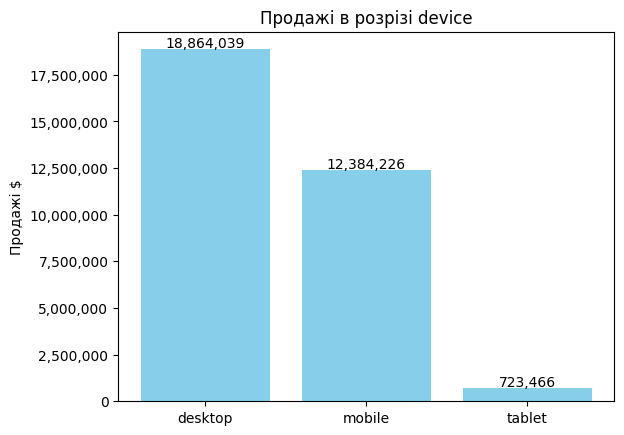

In [ ]:
plt.bar(order_by_device.index, order_by_device.values , color="skyblue")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

#додавання форматованих підписів над стовпцями
for i, value in enumerate(order_by_device.values):
     plt.text(i, value +100000,   f"{value:,.0f}",  fontsize=10, ha='center')

plt.title("Продажі в розрізі device")  # Title of the graph
# plt.xlabel("")  # X-axis label
plt.ylabel("Продажі $")  # Y-axis label
plt.show()

In [ ]:
# % від загальних продажів в розрізі девайсів
percent_by_device = ((order_by_device / total_price) * 100).round(2)

summary = pd.DataFrame({
    "Sales $": order_by_device.apply(lambda x: f"{x:,.0f}"),
    "% from total": percent_by_device
})
print(summary)

            Sales $  % from total
device                           
desktop  18,864,039         59.00
mobile   12,384,226         38.73
tablet      723,466          2.26


In [ ]:
#  аналізую продажі в розрізі каналів трафіку channel
order_by_channel = df.groupby("channel")["price"].sum().sort_values(ascending= False)
print(order_by_channel.apply(lambda x: f"{x:,.0f}$"))

channel
Organic Search    11,433,152$
Paid Search        8,511,049$
Direct             7,494,923$
Social Search      2,532,106$
Undefined          2,000,501$
Name: price, dtype: object


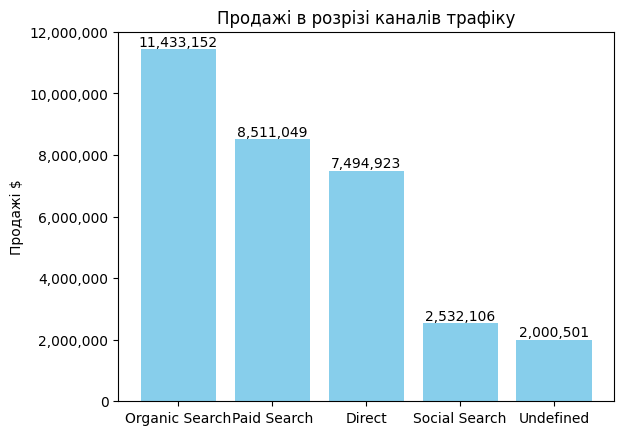

In [ ]:
plt.bar(order_by_channel.index, order_by_channel.values , color="skyblue")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

#додавання форматованих підписів над стовпцями
for i, value in enumerate(order_by_channel.values):
     plt.text(i, value +100000,   f"{value:,.0f}",  fontsize=10, ha='center')

plt.title("Продажі в розрізі каналів трафіку")  # Title of the graph
# plt.xlabel("")  # X-axis label
plt.ylabel("Продажі $")  # Y-axis label
plt.show()

In [ ]:
# % від загальних продажів в розрізі channel
percent_by_channel = ((order_by_channel / total_price) * 100).round(2)

summary_channel = pd.DataFrame({
    "Sales $": order_by_channel.apply(lambda x: f"{x:,.0f}"),
    "% from total": percent_by_channel
})
print(summary_channel)

                   Sales $  % from total
channel                                 
Organic Search  11,433,152         35.76
Paid Search      8,511,049         26.62
Direct           7,494,923         23.44
Social Search    2,532,106          7.92
Undefined        2,000,501          6.26


In [ ]:
#  аналізую продажі в розрізі джерел трафіку traffic_source
order_by_traffic_source = df.groupby("traffic_source")["price"].sum().sort_values(ascending= False)
print(order_by_traffic_source.apply(lambda x: f"{x:,.0f}$"))

traffic_source
(organic)         10,935,240$
(direct)           7,494,923$
<Other>            5,897,376$
(referral)         5,641,855$
(data deleted)     2,002,337$
Name: price, dtype: object


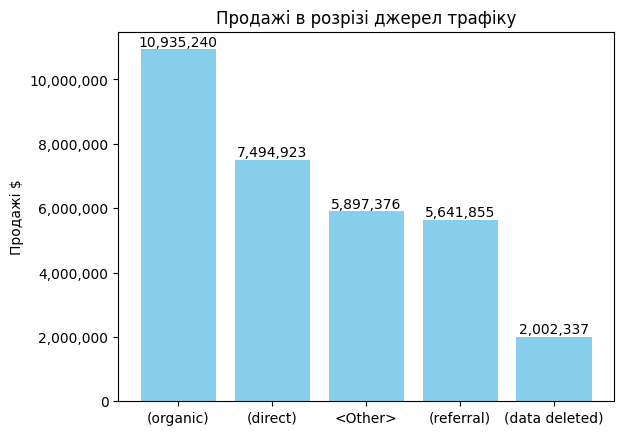

In [ ]:
plt.bar(order_by_traffic_source.index, order_by_traffic_source.values , color="skyblue")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

#додавання форматованих підписів над стовпцями
for i, value in enumerate(order_by_traffic_source.values):
     plt.text(i, value +100000,   f"{value:,.0f}",  fontsize=10, ha='center')

plt.title("Продажі в розрізі джерел трафіку")  # Title of the graph
# plt.xlabel("")  # X-axis label
plt.ylabel("Продажі $")  # Y-axis label
plt.show()

In [ ]:
# % від загальних продажів в розрізі джерел трафіку traffic_source
percent_by_traffic_source = ((order_by_traffic_source / total_price) * 100).round(2)

summary_traffic_source = pd.DataFrame({
    "Sales $": order_by_traffic_source.apply(lambda x: f"{x:,.0f}"),
    "% from total": percent_by_traffic_source
})
print(summary_traffic_source)

                   Sales $  % from total
traffic_source                          
(organic)       10,935,240         34.20
(direct)         7,494,923         23.44
<Other>          5,897,376         18.45
(referral)       5,641,855         17.65
(data deleted)   2,002,337          6.26


In [ ]:
acc_is_unsubscribed = df[df["is_unsubscribed"] == 1] # відписались
acc_is_subscribed = df[df["is_unsubscribed"] == 0] # підписані

acc_is_unsubscribed_cnt = acc_is_unsubscribed["account_id"].count()
acc_is_subscribed_cnt = acc_is_subscribed["account_id"].count()

print(f'Кількість зареєстрованих покупців які відписались від розсилки: {acc_is_unsubscribed_cnt} ')
print(f'Кількість зареєстрованих покупців які не відписались від розсилки: {acc_is_subscribed_cnt} ')

order_by_acc_is_unsubscribed = acc_is_unsubscribed["price"].sum()
order_by_acc_is_subscribed = acc_is_subscribed["price"].sum()

print(f'Сума продажів зареєстрованих покупців які відписались від розсилки: {order_by_acc_is_unsubscribed:,.0f}$')
print(f'Сума продажів зареєстрованих покупців які не відписались від розсилки:  {order_by_acc_is_subscribed:,.0f}$')

Кількість зареєстрованих покупців які відписались від розсилки: 4735 
Кількість зареєстрованих покупців які не відписались від розсилки: 23210 
Сума продажів зареєстрованих покупців які відписались від розсилки: 431,722$
Сума продажів зареєстрованих покупців які не відписались від розсилки:  2,150,797$


## Динаміка продажів

In [ ]:
# аналізую продажі по днях
order_by_date = df.groupby("date")["price"].sum()
print(order_by_date.apply(lambda x: f"{x:,.0f}$"))


date
2020-11-01    244,292$
2020-11-02    355,507$
2020-11-03    498,980$
2020-11-04    339,187$
2020-11-05    391,277$
                ...   
2021-01-27    286,341$
2021-01-28          0$
2021-01-29          0$
2021-01-30          0$
2021-01-31          0$
Name: price, Length: 92, dtype: object


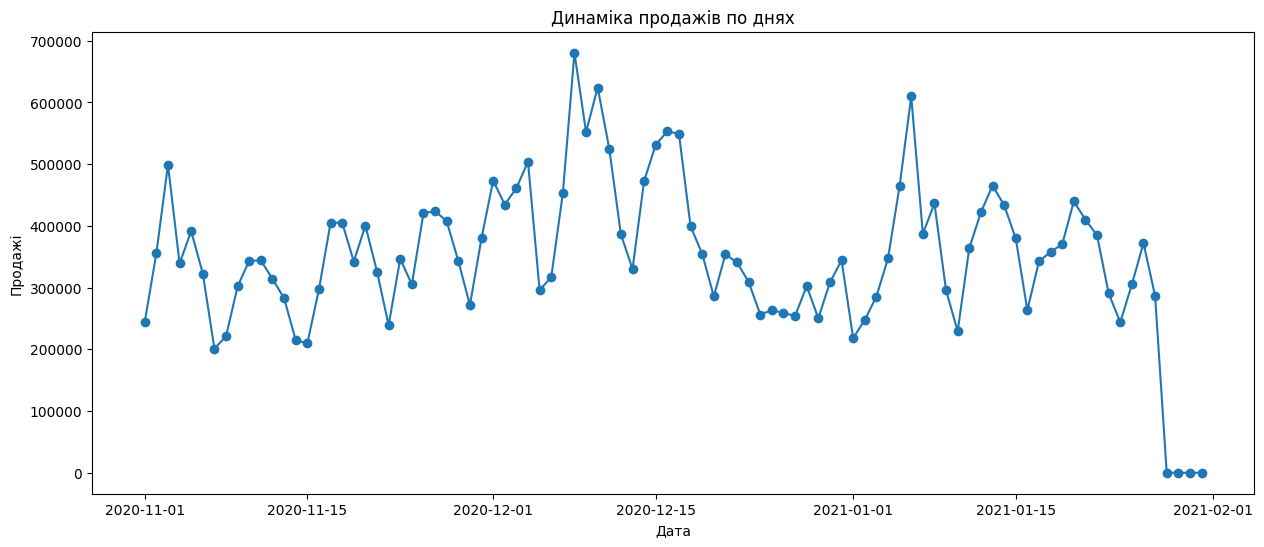

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(order_by_date.index, order_by_date.values, marker="o")
plt.title("Динаміка продажів по днях")  # Title of the graph
plt.xlabel("Дата")  # X-axis label
plt.ylabel("Продажі")  # Y-axis label
plt.show()

In [ ]:
import plotly.express as px

df_order_by_date = order_by_date.reset_index()

fig = px.line(
    df_order_by_date,
    x='date',
    y='price',
    markers=True,
    title='Динаміка продажів (інтерактивно)'
)

fig.update_layout(
    xaxis_title='Дата',
    yaxis_title='Продажі ($)',

    hovermode='x unified',
    yaxis=dict(tickformat=',.0f')
)

fig.show()

По динаміці продажів зрозуміло що є ознаки сезонності, зокрема, зростання продажів перед святами в грудні та зменшення після них.  
Є помітне зростання продажів у середині грудня 2020 року. Це може бути пов’язано з новорічними святами, коли споживча активність традиційно зростає.

Також є значний пік на початку січня - можливо, залишковий ефект святкових покупок або розпродажі після свят.

In [ ]:
# фільтрую датасет по топ-3 континентах
top_continent_by_order = df.groupby("continent")["price"].sum().sort_values(ascending= False).head(3)
top_continent = top_continent_by_order.index.tolist()

df_top_continent = df[df["continent"].isin(top_continent)]

df_top_continent["continent"].value_counts()


,count
continent,
Americas,193179
Asia,83113
Europe,65135


In [ ]:
# аналізую динаміку продажів в розрізі топ континентів
order_by_date_by_top_continent = df_top_continent.groupby(["date", "continent"])["price"].sum()
print(order_by_date_by_top_continent)

date        continent
2020-11-01  Americas     132002.5
            Asia          63823.0
            Europe        46908.0
2020-11-02  Americas     193861.0
            Asia          79370.0
                           ...   
2021-01-30  Asia              0.0
            Europe            0.0
2021-01-31  Americas          0.0
            Asia              0.0
            Europe            0.0
Name: price, Length: 276, dtype: float64


In [ ]:
# візуалізую динаміку продажів в розрізі топ континентів (інтерактивно)
df_order_by_date_by_continent = order_by_date_by_top_continent.reset_index()

fig = px.line(
    df_order_by_date_by_continent,
    x='date',
    y='price',
    color='continent',
    markers=True,
    title='Динаміка продажів у топ-3 континентах (інтерактивно)'
)

fig.update_layout(
    xaxis_title='Дата',
    yaxis_title='Продажі ($)',
    legend_title='Топ-3 континента',
    hovermode='x unified',
    yaxis=dict(tickformat=',.0f')
)

fig.show()

In [ ]:
# аналізую динаміку продажів в розрізі девайсів
order_by_date_by_device = df.groupby(["date", "device"])["price"].sum()
print(order_by_date_by_device)

date        device 
2020-11-01  desktop    144445.0
            mobile      99698.5
            tablet        149.0
2020-11-02  desktop    206727.3
            mobile     137269.5
                         ...   
2021-01-30  mobile          0.0
            tablet          0.0
2021-01-31  desktop         0.0
            mobile          0.0
            tablet          0.0
Name: price, Length: 276, dtype: float64


In [ ]:
# візуалізую динаміку продажів в розрізі топ континентів (інтерактивно)
df_order_by_date_by_device = order_by_date_by_device.reset_index()

fig = px.line(
    df_order_by_date_by_device,
    x='date',
    y='price',
    color='device',
    markers=True,
    title='Динаміка продажів у розрізі девайсів (інтерактивно)'
)

fig.update_layout(
    xaxis_title='Дата',
    yaxis_title='Продажі ($)',
    legend_title='Девайс',
    hovermode='x unified',
    yaxis=dict(tickformat=',.0f')
)

fig.show()

In [ ]:
# фільтрую датасет по топ-5 категоріях товарів
top_categoty_by_order = df.groupby("product_category")["price"].sum().sort_values(ascending= False).head(5)
top_category = top_categoty_by_order.index.tolist()
print(top_category)

df_top_category = df[df["product_category"].isin(top_category)]


['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards']


In [ ]:
# аналізую динаміку продажів в розрізі топ-5 категорій товарів
order_by_date_by_top_category = df_top_category.groupby(["date", "product_category"])["price"].sum()
print(order_by_date_by_top_category)

date        product_category          
2020-11-01  Beds                          14041.0
            Bookcases & shelving units    36701.0
            Cabinets & cupboards          13591.5
            Chairs                        46006.0
            Sofas & armchairs             75216.0
                                           ...   
2021-01-27  Beds                          43080.0
            Bookcases & shelving units    33874.2
            Cabinets & cupboards          29739.0
            Chairs                        48153.0
            Sofas & armchairs             51354.0
Name: price, Length: 440, dtype: float64


In [ ]:
df_order_by_date_by_top_category = order_by_date_by_top_category.reset_index()

fig = px.line(
    df_order_by_date_by_top_category,
    x='date',
    y='price',
    color='product_category',
    markers=True,
    title='Динаміка продажів у розрізі топ-5 категорій товарів (інтерактивно)'
)

fig.update_layout(
    xaxis_title='Дата',
    yaxis_title='Продажі ($)',
    legend_title='топ-5 категорії товарів',
    hovermode='x unified',
    yaxis=dict(tickformat=',.0f')
)

fig.show()

In [ ]:
# аналізую динаміку продажів в розрізі каналів трафіку
order_by_date_by_channel = df.groupby(["date", "channel"])["price"].sum()
print(order_by_date_by_channel)

date        channel       
2020-11-01  Direct            54669.5
            Organic Search    95112.0
            Paid Search       64688.0
            Social Search     25078.0
            Undefined          4745.0
                               ...   
2021-01-31  Direct                0.0
            Organic Search        0.0
            Paid Search           0.0
            Social Search         0.0
            Undefined             0.0
Name: price, Length: 460, dtype: float64


In [ ]:
df_order_by_date_by_channel = order_by_date_by_channel.reset_index()

fig = px.line(
    df_order_by_date_by_channel,
    x='date',
    y='price',
    color='channel',
    markers=True,
    title='Динаміка продажів у розрізі каналів трафіку (інтерактивно)'
)

fig.update_layout(
    xaxis_title='Дата',
    yaxis_title='Продажі ($)',
    legend_title='Канали трафіку',
    hovermode='x unified',
    yaxis=dict(tickformat=',.0f')
)

fig.show()

**Аналіз динаміки продажів**  



---
По динаміці продажів зрозуміло що є ознаки сезонності, зокрема, зростання продажів перед святами в грудні та зменшення після них.  
Є помітне зростання продажів у середині грудня 2020 року. Це може бути пов’язано з новорічними святами, коли споживча активність традиційно зростає.

Також є значний пік на початку січня - можливо, залишковий ефект святкових покупок або розпродажі після свят.


---
Продажі з desktop явно переважають протягом усього періоду.   

Найвищі піки спостерігаються:
*   близько 6–10 грудня (ймовірно, передсвяткові акції),
*   також на початку січня (можливо, післясвяткові розпродажі).  

Продажі з mobile дещо нижчі, але стабільні. Теж мають невеликі піки в грудні та на початку січня.  

Tablet демонструє найнижчі обсяги. Не має суттєвих піків, коливається в межах дуже малого доходу.


---

Найвищі значення продажів спостерігаються на континенті Americas:  
Чіткі піки в:
*   початку листопада,
*   середині грудня (≈6–10 грудня),
*   початку січня.

Asia — друге місце. Продажі стабільні, хоча значно нижчі за Америку. Піки менш виражені, купівельна активність стабільна і рівномірна.  
Найнижчі обсяги продажів по Європі, хоча не значно відрізняються від Asia. Піки є але незначні.


---
По категоріям товарів лідером за продажем стабільно є "Sofas & armchairs". Має виражені піки (особливо на початку листопаді та грудня), що може вказувати на акції чи сезонний попит (наприклад, перед святами).  
За нею слідує категорія "Chairs", яка показує більш стабільну динаміку. Значний пік спостерігається в першій половині грудня, що також може бути повязаним з передсвятковими акціями.   
Інші категорії: "Beds", "Bookcases & shelving units", "Cabinets & cupboards" показують менші продажі але тенденції до піків збігаються з попередніми категоріями.










## Зведені таблиці.


In [ ]:
# створюю зведену таблицю щоб проаналізувати кількість замовлень в розрізі джерел трафіку і девайсам
pivot_tab_1 = df.groupby(["channel", "device"])["price"].count().unstack()
print(pivot_tab_1)

device          desktop  mobile  tablet
channel                                
Direct             4655    2985     160
Organic Search     7011    4655     255
Paid Search        5261    3574     207
Social Search      1594    1065      57
Undefined          1181     834      44


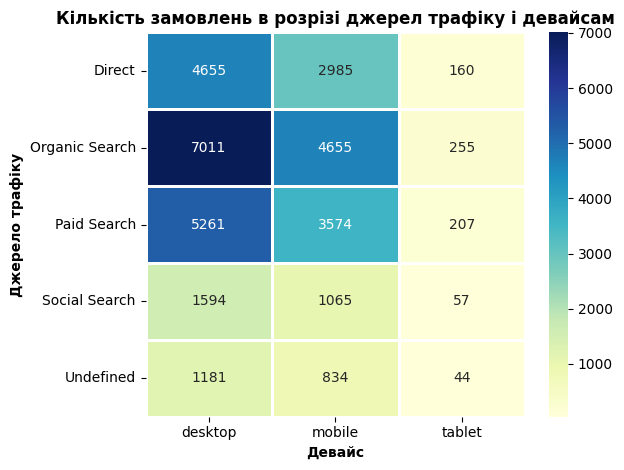

In [ ]:
import seaborn as sns


sns.heatmap(pivot_tab_1, annot=True, fmt=".0f", cmap='YlGnBu', linewidths=1)
plt.title('Кількість замовлень в розрізі джерел трафіку і девайсам', fontweight='bold')
plt.xlabel('Девайс', fontweight='bold')
plt.ylabel('Джерело трафіку', fontweight='bold')
plt.tight_layout()
plt.show()

Найбільше замовлень здійснювали користувачі, які прийшли з органічного пошуку на десктопах.

In [ ]:
# створюю датасет з топ-10 категорій товарів і топ-5 країн
top10_category_order = df.groupby("product_category")["price"].sum().sort_values(ascending= False).head(10)
top10_category = top10_category_order.index.tolist()



top5_country_order = df.groupby("country")["price"].sum().sort_values(ascending= False).head(5)
top5_country = top5_country_order.index.tolist()

df_top10_category = df["product_category"].isin(top10_category)
df_top5_country = df["country"].isin(top5_country)



df_top10_category_top5_country = df[df_top10_category & df_top5_country]


In [ ]:
# створюю зведену таблицю щоб проаналізуати продажі в розрізі топ 10 категорій і топ 5 країнам.

pivot_table_2 = df_top10_category_top5_country.groupby(["product_category", "country"])["price"].sum().unstack()
print(pivot_table_2)

country                             Canada    France     India  \
product_category                                                 
Bar furniture                      51724.0   11199.0   57657.0   
Beds                              354772.0  116414.0  358319.5   
Bookcases & shelving units        278981.9   73830.0  364507.4   
Cabinets & cupboards              181802.0   59101.5  191888.0   
Chairs                            417740.8  134029.4  544309.2   
Chests of drawers & drawer units   71952.0   21544.5   73111.0   
Children's furniture               30264.0   14258.0   39177.0   
Outdoor furniture                 185322.8   40486.4  162289.4   
Sofas & armchairs                 692427.5  187735.0  788430.0   
Tables & desks                    132678.0   42299.0  186157.5   

country                           United Kingdom  United States  
product_category                                                 
Bar furniture                            22103.0       330805.0  
Beds     

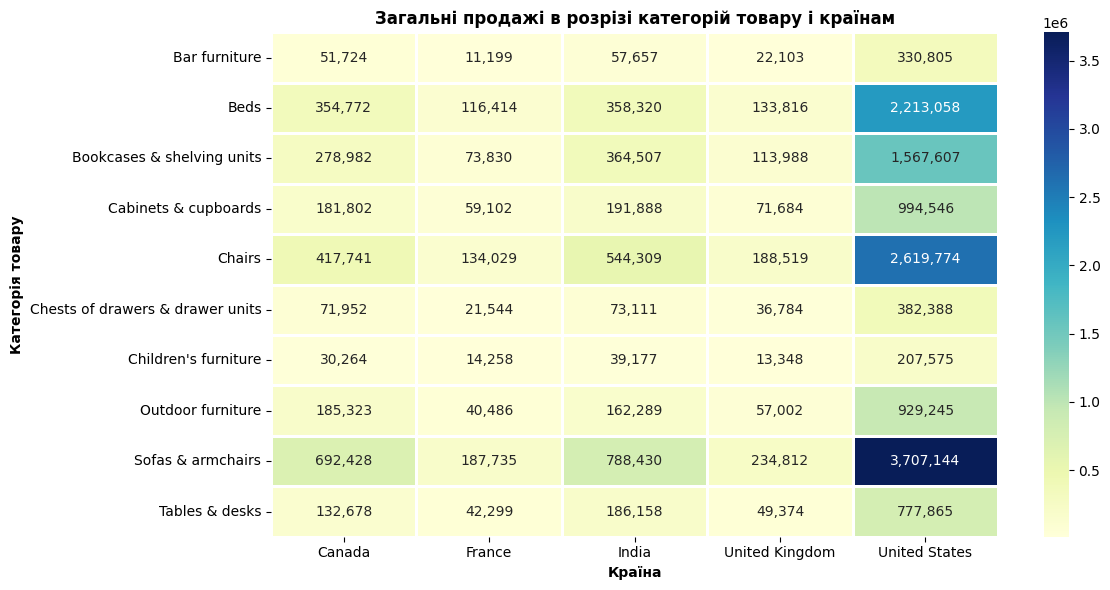

In [ ]:
# візуалізую зведену таблицю
plt.figure(figsize=(12, 6))

sns.heatmap(pivot_table_2, annot=True, fmt=",.0f", cmap='YlGnBu', linewidths=1)
plt.title('Загальні продажі в розрізі категорій товару і країнам', fontweight='bold')
plt.xlabel('Країна', fontweight='bold')
plt.ylabel('Категорія товару', fontweight='bold')
plt.tight_layout()
plt.show()

Найбільші продажі в United States  по категорії Sofas & armchairs.

In [ ]:
# створюю стовпчик місяця

df["year_month"] = df["date"].dt.to_period("M").dt.to_timestamp()
df.head()

,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,browser_language,traffic_source,channel,account_id,is_verified,is_unsubscribed,product_category,product_name,price,short_description,year_month
0,2021-01-19,7268004754,(not set),(not set),desktop,Chrome,Chrome,Web,en-gb,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None,2021-01-01
1,2021-01-06,8321293308,(not set),(not set),desktop,Chrome,Chrome,Web,(not set),(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None,2021-01-01
2,2020-11-05,4392362373,(not set),(not set),desktop,Chrome,Chrome,Web,(not set),(organic),Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None,2020-11-01
3,2020-12-09,140108698,(not set),(not set),desktop,Chrome,Safari,Web,en-us,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None,2020-12-01
4,2020-11-10,8351127264,(not set),(not set),mobile,Safari,iPhone,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None,2020-11-01


In [ ]:
# фільтрую по топ-10 категорій товарів

df_top5_category = df[df["product_category"].isin(top_category)]


In [ ]:
# створюю зведену таблицю для аналізу кількості замовлень в розрізі місяців і топ 5 категорій товарів

pivot_table_3 = df_top5_category.groupby(["product_category", "year_month"])["price"].count().unstack()
pivot_table_3.columns = pivot_table_3.columns.strftime('%b %Y')
print(pivot_table_3)

year_month                  Nov 2020  Dec 2020  Jan 2021
product_category                                        
Beds                             895      1150       881
Bookcases & shelving units      2466      2920      2244
Cabinets & cupboards             685       937       696
Chairs                          1821      2333      1798
Sofas & armchairs               1393      1627      1281


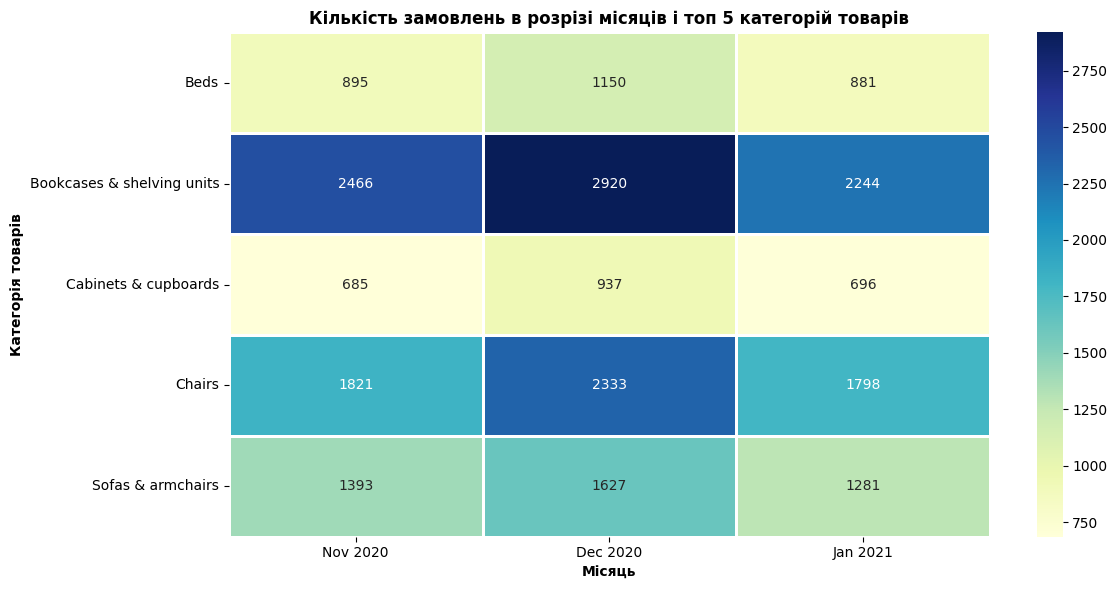

In [ ]:
import matplotlib.dates as mdates
plt.figure(figsize=(12, 6))

sns.heatmap(pivot_table_3, annot=True, fmt=".0f", cmap='YlGnBu', linewidths=1)
plt.title('Кількість замовлень в розрізі місяців і топ 5 категорій товарів', fontweight='bold')
plt.xlabel('Місяць', fontweight='bold')

plt.ylabel('Категорія товарів', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# створюю зведену таблицю для аналізу продажів в розрізі місяців і топ 5 категорій товарів

pivot_table_4 = df_top5_category.groupby(["product_category", "year_month"])["price"].sum().unstack()
pivot_table_4.columns = pivot_table_4.columns.strftime('%b %Y')
print(pivot_table_4)

year_month                   Nov 2020   Dec 2020   Jan 2021
product_category                                           
Beds                        1396037.0  2021144.5  1502543.5
Bookcases & shelving units  1178001.3  1394184.8  1068632.0
Cabinets & cupboards         707734.5   953360.5   675404.5
Chairs                      1804219.8  2450217.6  1893311.4
Sofas & armchairs           2773289.0  3102871.0  2512094.5


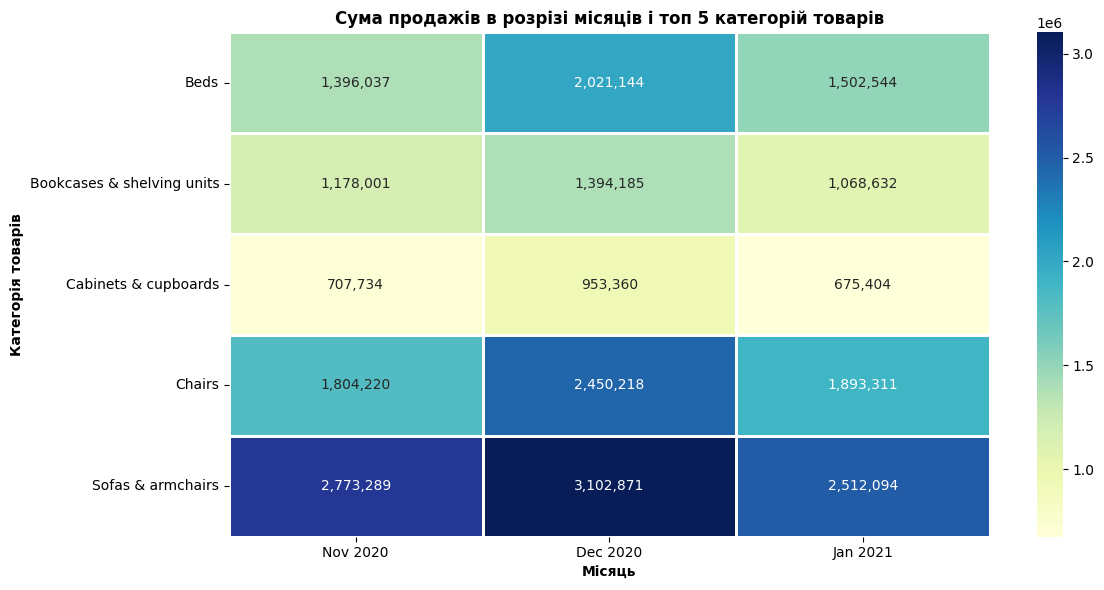

In [ ]:

plt.figure(figsize=(12, 6))

sns.heatmap(pivot_table_4, annot=True, fmt=",.0f", cmap='YlGnBu', linewidths=1)
plt.title('Сума продажів в розрізі місяців і топ 5 категорій товарів', fontweight='bold')
plt.xlabel('Місяць', fontweight='bold')

plt.ylabel('Категорія товарів', fontweight='bold')
plt.tight_layout()
plt.show()

Висновок:

Аналіз кількості замовлень і суми продажів по місяцях та категоріях товарів показав наступне:

- Категорія "Bookcases & shelving units" має найбільшу кількість замовлень у більшості місяців.

- Водночас, категорія "Sofas & armchairs" демонструє найвищу суму продажів, попри меншу кількість транзакцій.

Це свідчить про те, що товари в категорії "Sofas & armchairs" мають вищу середню ціну, що й зумовлює її лідерство за сумарною виручкою.

## Статистичний аналіз взаємозв’язків.

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import normaltest, shapiro
from scipy.stats import kendalltau

### Проаналізую чи є взаємозв'язок між кількістю сесій та загальними продажами

In [ ]:
# ствоюю датасет кількість сесій та загальні продажі за кожну дату
df_sales_by_date = df.groupby('date').agg(
    session_count=('ga_session_id', 'count'),
    total_sales=('price', 'sum')
).reset_index()
df_sales_by_date.head()

,date,session_count,total_sales
0,2020-11-01,2576,244292.5
1,2020-11-02,3599,355506.8
2,2020-11-03,5173,498979.6
3,2020-11-04,4184,339187.1
4,2020-11-05,3743,391276.6


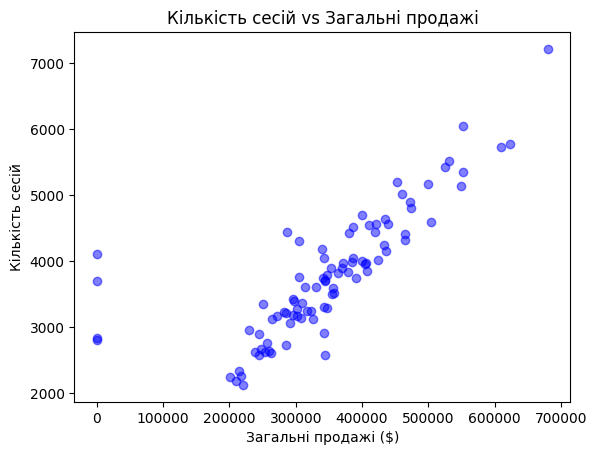

In [ ]:
# візуалізую взаємозв'язок між змінними за допомогою діаграми розсіювання

plt.scatter(df_sales_by_date["total_sales"], df_sales_by_date["session_count"], color="blue", alpha=0.5)
plt.title("Кількість сесій vs Загальні продажі")  # Title of the graph
plt.xlabel("Загальні продажі ($)")  # X-axis label
plt.ylabel("Кількість сесій")  # Y-axis label
plt.show()

З графіка простежується пряма заледність між кількістю сесій і загальними продажами.

for session_count:
Normaltest p-value: 0.008655428822366544
Shapiro-Wilk p-value: 0.026201156314308208

for total_sales:
Normaltes p-value: 0.021085752302202193
Shapiro-Wilk p-value: 0.0017206798751357067


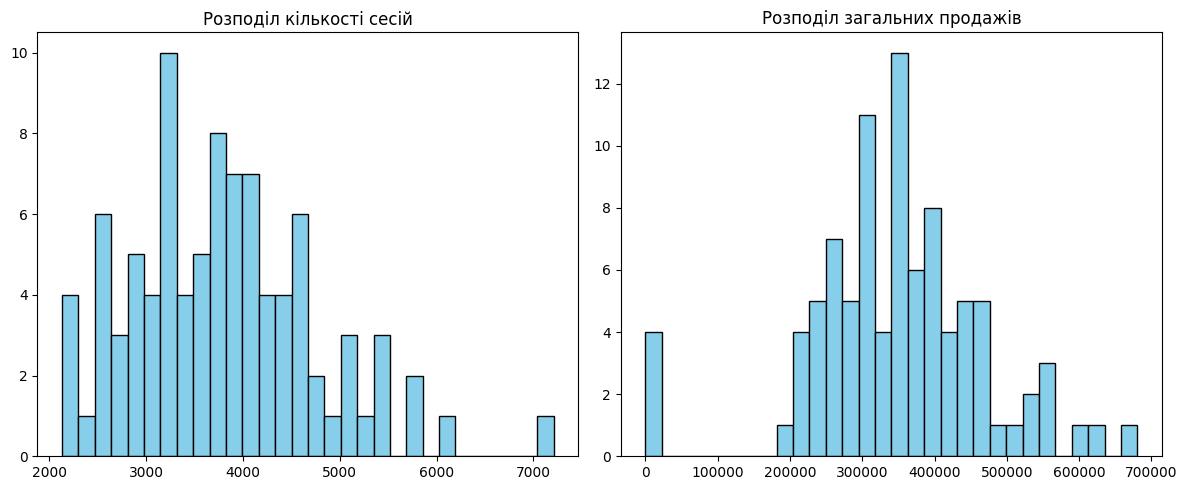

In [ ]:
# за допомогою тестів Д'Агостіно-Пірсона і Шапіро-Уілка і візуалізації, досліджую розподіли на нормальність

plt.figure(figsize=(12, 5))

_, p_value_normaltest_session_count = normaltest(df_sales_by_date["session_count"])
_, p_value_normaltest_total_sales = normaltest(df_sales_by_date["total_sales"])

_, p_value_shapiro_session_count = shapiro(df_sales_by_date["session_count"])
_, p_value_shapiro_total_sales = shapiro(df_sales_by_date["total_sales"])

print("for session_count:")
print(f"Normaltest p-value: {p_value_normaltest_session_count}")
print(f"Shapiro-Wilk p-value: {p_value_shapiro_session_count}")

print("\nfor total_sales:")
print(f"Normaltes p-value: {p_value_normaltest_total_sales}")
print(f"Shapiro-Wilk p-value: {p_value_shapiro_total_sales}")





plt.subplot(1, 2, 1)
plt.hist(df_sales_by_date["session_count"], bins=30, color="skyblue", edgecolor="black")
plt.title("Розподіл кількості сесій")

plt.subplot(1, 2, 2)
plt.hist(df_sales_by_date["total_sales"], bins=30, color="skyblue", edgecolor="black")
plt.title("Розподіл загальних продажів")

plt.tight_layout()
plt.show()


Обидва тести (Normaltest і Shapiro-Wilk) дають статистично значущі результати, тобто відхиляють нульову гіпотезу про нормальність,  оскільки p-value < 0.05, і це означає, що:  
змінні session_count і total_sales не мають нормального розподілу.  
Для дослідження зв’язку між цими змінними краще використовувати кореляцію Спірмена або Кендалла.

In [ ]:
# визначаю коефіцієнт Спірмена

print(f"Test statistic and p-value:\n {spearmanr(df_sales_by_date['total_sales'], df_sales_by_date['session_count'])}")

spearman_corr = df_sales_by_date["total_sales"].corr(df_sales_by_date["session_count"], method="spearman")
print(f"Spearman Correlation: {spearman_corr}")


Test statistic and p-value:
 SignificanceResult(statistic=np.float64(0.865306217456368), pvalue=np.float64(9.755923586156684e-29))
Spearman Correlation: 0.865306217456368


Згідно з коефіцієнтом Спірмена між загальними продажами і кількістю сесій існує сильний і статистично значущий зв’язок .

In [ ]:
print(f"Test statistic and p-value: {kendalltau(df_sales_by_date['total_sales'], df_sales_by_date['session_count'])}")

# Calculate Kendall's Tau correlation
kendall_corr = df_sales_by_date["total_sales"].corr(df_sales_by_date["session_count"], method="kendall")
print(f"Kendall Correlation: {kendall_corr}")

Test statistic and p-value: SignificanceResult(statistic=np.float64(0.717666930923723), pvalue=np.float64(4.2515191569599826e-24))
Kendall Correlation: 0.717666930923723


Згідно з коефіцієнтом кореляції Кендала, між загальними продажами і кількістю сесій спостерігається сильний додатній ранговий зв’язок, тобто зі збільшенням значень однієї змінної зростають і значення іншої.

Низьке значення p-value (< 0.05) вказує на те, що цей зв’язок є статистично значущим і він не є випадковим.

### Досліджую чи корелюють між собою продажі на різних континентах(топ-3)


In [ ]:
# створюю датасет доя топ-3 континентів
sales_by_top3_continents = df.groupby("continent")["price"].sum().sort_values(ascending= False).head(3)
top3_continents = sales_by_top3_continents.index.tolist()
print(top3_continents)

df_by_top3_continents = df[df["continent"].isin(top3_continents)]

df_by_top3_continents.head()

['Americas', 'Asia', 'Europe']


,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,browser_language,traffic_source,channel,account_id,is_verified,is_unsubscribed,product_category,product_name,price,short_description,year_month
482,2020-12-11,9954897785,Asia,Japan,mobile,Chrome,Pixel 4 XL,Web,(not set),<Other>,Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None,2020-12-01
483,2021-01-29,6748985634,Asia,Pakistan,mobile,Chrome,Pixel 4 XL,Web,(not set),(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None,2021-01-01
484,2020-12-25,8058693541,Asia,Turkey,mobile,Chrome,Pixel 4 XL,Web,(not set),(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None,2020-12-01
485,2021-01-29,984887898,Asia,China,mobile,Chrome,Pixel 3,Web,en-gb,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None,2021-01-01
486,2020-12-06,8043333799,Asia,South Korea,mobile,Chrome,Pixel 3,Web,(not set),<Other>,Paid Search,<NA>,<NA>,<NA>,None,None,NaN,None,2020-12-01


In [ ]:
# згрупую за датою і континентом

sales_by_date_and_continent = df_by_top3_continents.groupby(["date","continent"])["price"].sum().unstack()
sales_by_date_and_continent.head()

continent,Americas,Asia,Europe
date,,,
2020-11-01,132002.5,63823.0,46908.0
2020-11-02,193861.0,79370.0,75710.8
2020-11-03,294529.8,126737.8,67692.0
2020-11-04,200009.5,66602.0,65915.0
2020-11-05,182988.2,117608.4,86540.0


Americas:
Normaltest p-value: 0.09926339704137344
Shapiro-Wilk p-value: 0.01954332601296497

for Asia:
Normaltes p-value: 0.20905672433615619
Shapiro-Wilk p-value: 0.0036310321229958407

for Europe:
Normaltest p-value: 0.1310345844691827
Shapiro-Wilk p-value: 0.035864188219443725


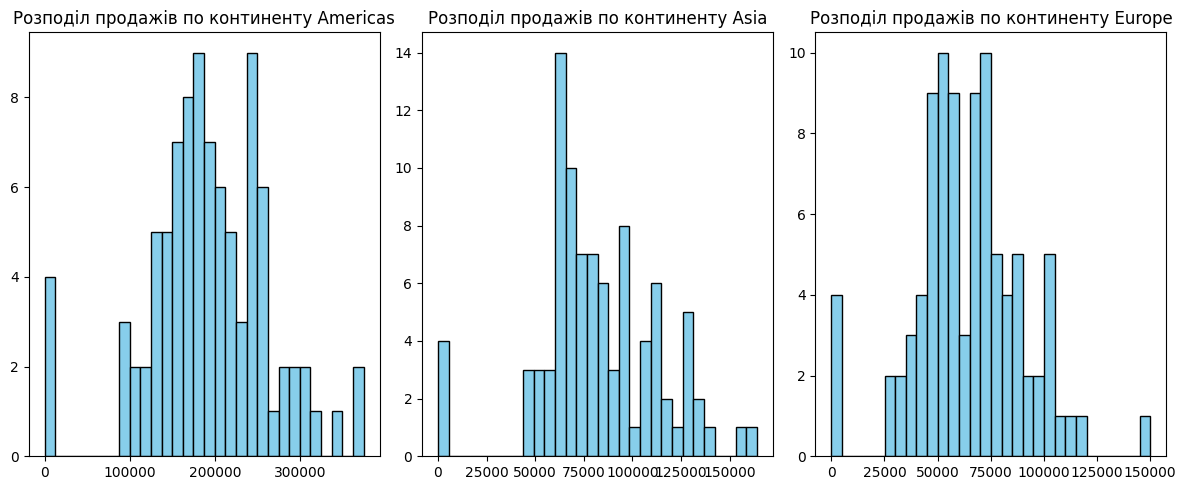

In [ ]:
# досліджую розподіли на нормальність за допомогою тестів Д'Агостіно-Пірсона і Шапіро-Уілка і візуалізації

plt.figure(figsize=(12, 5))

_, p_value_normaltest_Americas = normaltest(sales_by_date_and_continent["Americas"])
_, p_value_normaltest_Asia = normaltest(sales_by_date_and_continent["Asia"])
_, p_value_normaltest_Europe = normaltest(sales_by_date_and_continent["Europe"])

_, p_value_shapiro_Americas = shapiro(sales_by_date_and_continent["Americas"])
_, p_value_shapiro_Asia = shapiro(sales_by_date_and_continent["Asia"])
_, p_value_shapiro_Europe = shapiro(sales_by_date_and_continent["Europe"])

print("Americas:")
print(f"Normaltest p-value: {p_value_normaltest_Americas}")
print(f"Shapiro-Wilk p-value: {p_value_shapiro_Americas}")

print("\nfor Asia:")
print(f"Normaltes p-value: {p_value_normaltest_Asia}")
print(f"Shapiro-Wilk p-value: {p_value_shapiro_Asia}")

print("\nfor Europe:")
print(f"Normaltest p-value: {p_value_normaltest_Europe}")
print(f"Shapiro-Wilk p-value: {p_value_shapiro_Europe}")



plt.subplot(1, 3, 1)
plt.hist(sales_by_date_and_continent["Americas"], bins=30, color="skyblue", edgecolor="black")
plt.title("Розподіл продажів по континенту Americas")

plt.subplot(1, 3, 2)
plt.hist(sales_by_date_and_continent["Asia"], bins=30, color="skyblue", edgecolor="black")
plt.title("Розподіл продажів по континенту Asia")

plt.subplot(1, 3, 3)
plt.hist(sales_by_date_and_continent["Europe"], bins=30, color="skyblue", edgecolor="black")
plt.title("Розподіл продажів по континенту Europe")

plt.tight_layout()
plt.show()


Вважаємо що наші розподіли не є нормальними, тому що якщо хоч один із тестів показує статистично значуще відхилення від нормальності (тобто p-value < 0.05), тоді розподіл вважається не нормальним.

In [ ]:
# визначаю коефіцієнт Спірмена для взаємозв'язку продажів по континентах Americas і Asia

print(f"Test statistic spearman and p-value:\n {spearmanr(sales_by_date_and_continent['Americas'], sales_by_date_and_continent['Asia'])}")

spearman_corr = sales_by_date_and_continent['Americas'].corr(sales_by_date_and_continent['Asia'], method="spearman")
print(f"Spearman Correlation: {spearman_corr}")


# визначаю коефіцієнт Кендала для взаємозв'язку продажів по континентах Americas і Asia

print(f"\nTest statistic kendall and p-value:\n {kendalltau(sales_by_date_and_continent['Americas'], sales_by_date_and_continent['Asia'])}")

# Calculate Kendall's Tau correlation
kendall_corr = sales_by_date_and_continent['Americas'].corr(sales_by_date_and_continent['Asia'], method="kendall")
print(f"Kendall Correlation: {kendall_corr}")

Test statistic spearman and p-value:
 SignificanceResult(statistic=np.float64(0.7099016615801969), pvalue=np.float64(2.3233796296203977e-15))
Spearman Correlation: 0.7099016615801969

Test statistic kendall and p-value:
 SignificanceResult(statistic=np.float64(0.517224880382775), pvalue=np.float64(3.0377068315356127e-13))
Kendall Correlation: 0.517224880382775


Коефіцієнт кореляції Спірмена становить 0.7 і коефіцієн Кендала 0.52, що свідчить про позитивну кореляцію між продажами по континентах Americas і Asia, і так як p-value по двох коефіцієнтах значно менше 0.05 (p-value = 2.32e-15) то результат статистично значущий.  
Така кореляція може свідчити про вплив спільних глобальних чинників (наприклад, сезонних кампаній, міжнародних трендів або одночасних маркетингових активностей компанії).

In [ ]:
# визначаю коефіцієнт Спірмена для взаємозв'язку продажів на континентах Americas і Europe

print(f"Test statistic spearman and p-value:\n {spearmanr(sales_by_date_and_continent['Americas'], sales_by_date_and_continent['Europe'])}")

spearman_corr = sales_by_date_and_continent['Americas'].corr(sales_by_date_and_continent['Europe'], method="spearman")
print(f"Spearman Correlation: {spearman_corr}")


# визначаю коефіцієнт Кендала для взаємозв'язку продажів на континентах Americas і Europe

print(f"\nTest statistic kendall and p-value:\n {kendalltau(sales_by_date_and_continent['Americas'], sales_by_date_and_continent['Europe'])}")

# Calculate Kendall's Tau correlation
kendall_corr = sales_by_date_and_continent['Americas'].corr(sales_by_date_and_continent['Europe'], method="kendall")
print(f"Kendall Correlation: {kendall_corr}")



Test statistic spearman and p-value:
 SignificanceResult(statistic=np.float64(0.6725700545639509), pvalue=np.float64(2.1035588726455927e-13))
Spearman Correlation: 0.6725700545639509

Test statistic kendall and p-value:
 SignificanceResult(statistic=np.float64(0.4985645933014354), pvalue=np.float64(2.071110421868149e-12))
Kendall Correlation: 0.4985645933014354


Між продажами на континентах Americas і Europe існує сильний позитивний кореляційний взаємозв'язок:  
- Коефіцієнт Спірмена: 0.673

- Коефіцієнт Кендалла: 0.499

- p-value для обох тестів < 0.05, що свідчить про статистичну значущість цього взаємозв’язку.

Це означає, що тенденції змін обсягів продажів у цих двох регіонах збігаються: зростання або спад продажів в одному регіоні зазвичай супроводжується аналогічним рухом в іншому.

In [ ]:
# визначаю коефіцієнт Спірмена для взаємозв'язку продажів на континентах Europe і Asia

print(f"Test statistic spearman and p-value:\n {spearmanr(sales_by_date_and_continent['Europe'], sales_by_date_and_continent['Asia'])}")

spearman_corr = sales_by_date_and_continent['Europe'].corr(sales_by_date_and_continent['Asia'], method="spearman")
print(f"Spearman Correlation: {spearman_corr}")


# визначаю коефіцієнт Кендала для взаємозв'язку продажів на континентах Europe і Asia

print(f"\nTest statistic kendall and p-value:\n {kendalltau(sales_by_date_and_continent['Europe'], sales_by_date_and_continent['Asia'])}")

# Calculate Kendall's Tau correlation
kendall_corr = sales_by_date_and_continent['Europe'].corr(sales_by_date_and_continent['Asia'], method="kendall")
print(f"Kendall Correlation: {kendall_corr}")


Test statistic spearman and p-value:
 SignificanceResult(statistic=np.float64(0.6571102685039614), pvalue=np.float64(1.1290947217450973e-12))
Spearman Correlation: 0.6571102685039614

Test statistic kendall and p-value:
 SignificanceResult(statistic=np.float64(0.48086124401913877), pvalue=np.float64(1.2017712788503667e-11))
Kendall Correlation: 0.48086124401913877


Між продажами на континентах Asia та Europe також спостерігається сильна позитивна кореляція:
- Коефіцієнт Спірмена: 0.657
- Коефіцієнт Кендалла: 0.481
- p-value для обох тестів < 0.05, тобто зв’язок статистично значущий.
Це свідчить про те, що динаміка продажів на обох континентах має схожу тенденцію: коли зростають (чи зменшуються) продажі в Азії, аналогічна зміна часто спостерігається і в Європі.

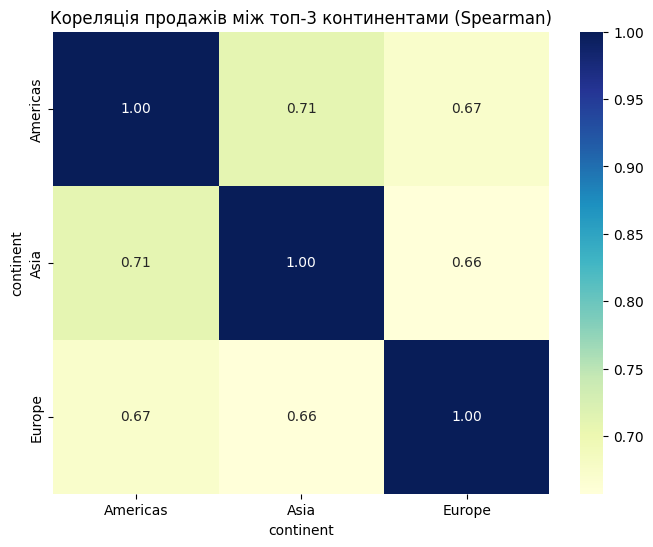

In [ ]:
# візуалізую за допомого теплової карти

# Кореляція Спірмена
corr_matrix = sales_by_date_and_continent.corr(method='spearman')

# Теплова карта
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Кореляція продажів між топ-3 континентами (Spearman)")
plt.show()

### Досліджую чи корелюють між собою продажі за різними каналами трафіку?

In [ ]:
# групую по каналах трафіку
sales_by_channal = df.groupby(["date","channel"])["price"].sum().sort_values(ascending= False).unstack()
print(sales_by_channal)

channel       Direct  Organic Search  Paid Search  Social Search  Undefined
date                                                                       
2020-11-01   54669.5         95112.0      64688.0        25078.0     4745.0
2020-11-02   81561.5        127746.5     104780.8        16843.0    24575.0
2020-11-03  102909.5        182521.9     152641.3        27652.5    33254.4
2020-11-04   79683.6        117067.1     100332.0        24257.4    17847.0
2020-11-05   83367.6        122938.4     107648.0        41693.2    35629.4
...              ...             ...          ...            ...        ...
2021-01-27   70423.1         92921.1      80869.5        16282.0    25845.0
2021-01-28       0.0             0.0          0.0            0.0        0.0
2021-01-29       0.0             0.0          0.0            0.0        0.0
2021-01-30       0.0             0.0          0.0            0.0        0.0
2021-01-31       0.0             0.0          0.0            0.0        0.0

[92 rows x 

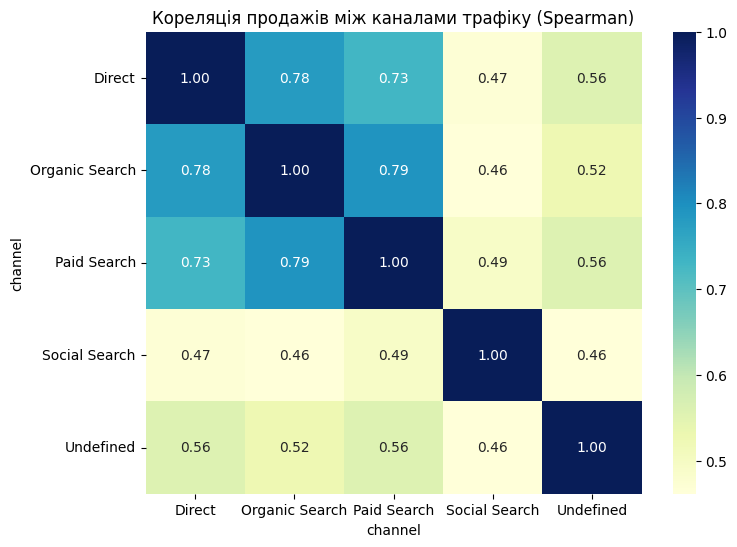

In [ ]:
# візуалізую за допомого теплової карти

# Кореляція Спірмена
corr_matrix_by_channal = sales_by_channal.corr(method='spearman')

# Теплова карта
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_by_channal, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Кореляція продажів між каналами трафіку (Spearman)")
plt.show()

In [ ]:
# кореляція між Direct і Organic Search
print(f"Test statistic spearman and p-value Direct and Organic Search:\n {spearmanr(sales_by_channal['Direct'], sales_by_channal['Organic Search'])}")
spearman_corr_channal = sales_by_channal['Direct'].corr(sales_by_channal['Organic Search'], method="spearman")
print(f"Spearman Correlation: {spearman_corr_channal}")

# кореляція між Direct і Paid Search
print(f"\nTest statistic spearman and p-value Direct and Paid Search:\n {spearmanr(sales_by_channal['Direct'], sales_by_channal['Paid Search'])}")
spearman_corr_channal = sales_by_channal['Direct'].corr(sales_by_channal['Paid Search'], method="spearman")
print(f"Spearman Correlation: {spearman_corr_channal}")

# кореляція між Direct і Social Search
print(f"\nTest statistic spearman and p-value Direct and Social Search:\n {spearmanr(sales_by_channal['Direct'], sales_by_channal['Social Search'])}")
spearman_corr_channal = sales_by_channal['Direct'].corr(sales_by_channal['Social Search'], method="spearman")
print(f"Spearman Correlation: {spearman_corr_channal}")

# кореляція між Direct і Undefined
print(f"\nTest statistic spearman and p-value Direct і Undefined:\n {spearmanr(sales_by_channal['Direct'], sales_by_channal['Undefined'])}")
spearman_corr_channal = sales_by_channal['Direct'].corr(sales_by_channal['Undefined'], method="spearman")
print(f"Spearman Correlation: {spearman_corr_channal}")

# кореляція між Organic Search і Paid Search
print(f"\nTest statistic spearman and p-value Organic Search and Paid Search:\n {spearmanr(sales_by_channal['Organic Search'], sales_by_channal['Paid Search'])}")
spearman_corr_channal = sales_by_channal['Organic Search'].corr(sales_by_channal['Paid Search'], method="spearman")
print(f"Spearman Correlation: {spearman_corr_channal}")

# кореляція між Organic Search і Social Search
print(f"\nTest statistic spearman and p-value Organic Search and Social Search:\n {spearmanr(sales_by_channal['Organic Search'], sales_by_channal['Social Search'])}")
spearman_corr_channal = sales_by_channal['Organic Search'].corr(sales_by_channal['Social Search'], method="spearman")
print(f"Spearman Correlation: {spearman_corr_channal}")

# кореляція між Organic Search і Undefined
print(f"\nTest statistic spearman and p-value Organic Search and Undefined:\n {spearmanr(sales_by_channal['Organic Search'], sales_by_channal['Undefined'])}")
spearman_corr_channal = sales_by_channal['Organic Search'].corr(sales_by_channal['Undefined'], method="spearman")
print(f"Spearman Correlation: {spearman_corr_channal}")

# кореляція між Paid Search і Social Search
print(f"\nTest statistic spearman and p-value Paid Search and Social Search:\n {spearmanr(sales_by_channal['Paid Search'], sales_by_channal['Social Search'])}")
spearman_corr_channal = sales_by_channal['Paid Search'].corr(sales_by_channal['Social Search'], method="spearman")
print(f"Spearman Correlation: {spearman_corr_channal}")

# кореляція між Paid Search і Undefined
print(f"\nTest statistic spearman and p-value Paid Search and Undefined:\n {spearmanr(sales_by_channal['Paid Search'], sales_by_channal['Undefined'])}")
spearman_corr_channal = sales_by_channal['Paid Search'].corr(sales_by_channal['Undefined'], method="spearman")
print(f"Spearman Correlation: {spearman_corr_channal}")

# кореляція між Social Search і Undefined
print(f"\nTest statistic spearman and p-value Social Search and Undefined:\n {spearmanr(sales_by_channal['Social Search'], sales_by_channal['Undefined'])}")
spearman_corr_channal = sales_by_channal['Social Search'].corr(sales_by_channal['Undefined'], method="spearman")
print(f"Spearman Correlation: {spearman_corr_channal}")

Test statistic spearman and p-value Direct and Organic Search:
 SignificanceResult(statistic=np.float64(0.7796633681679461), pvalue=np.float64(5.405253983075643e-20))
Spearman Correlation: 0.7796633681679461

Test statistic spearman and p-value Direct and Paid Search:
 SignificanceResult(statistic=np.float64(0.729368969450353), pvalue=np.float64(1.65402161751709e-16))
Spearman Correlation: 0.729368969450353

Test statistic spearman and p-value Direct and Social Search:
 SignificanceResult(statistic=np.float64(0.46934245815222425), pvalue=np.float64(2.365556386712662e-06))
Spearman Correlation: 0.46934245815222425

Test statistic spearman and p-value Direct і Undefined:
 SignificanceResult(statistic=np.float64(0.556922223249792), pvalue=np.float64(8.156166744014837e-09))
Spearman Correlation: 0.556922223249792

Test statistic spearman and p-value Organic Search and Paid Search:
 SignificanceResult(statistic=np.float64(0.7933814235950555), pvalue=np.float64(4.16183654939949e-21))
Spearma

Всі пари каналів трафіку мають позитивну кореляцію, тобто зростання продажів в одному каналі зазвичай супроводжується зростанням в іншому.

Значення коефіцієнта Спірмена коливаються від 0.46 до 0.79, що свідчить про помірну до сильної кореляції.

Усі p-value < 0.05, що дає підстави вважати, що ці зв’язки є статистично значущими - тобто з високою ймовірністю не випадковими.

### Досліджую чи корелюються між собою продажі за топ-5 категоріями товарів?

In [ ]:
# створюю датасет тільки по топ 5 категоріях товарів
top5_category = df.groupby("product_category")["price"].sum().sort_values(ascending= False).head(5)
top5_category = top5_category.index.tolist()
print(top5_category)

df_by_top5_category = df[df["product_category"].isin(top5_category)]

df_by_top5_category.head()

['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards']


,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,browser_language,traffic_source,channel,account_id,is_verified,is_unsubscribed,product_category,product_name,price,short_description,year_month
12,2020-12-24,5726438444,(not set),(not set),desktop,Chrome,Chrome,Web,(not set),(referral),Paid Search,<NA>,<NA>,<NA>,Cabinets & cupboards,LIXHULT,356.0,"Wall-mounted cabinet combination, 50x25x50 cm",2020-12-01
39,2020-11-05,8542454082,(not set),(not set),desktop,Chrome,Safari,Web,en-us,(data deleted),Undefined,<NA>,<NA>,<NA>,Chairs,ANTILOP,20.0,Cover,2020-11-01
41,2020-12-16,1717992506,(not set),(not set),mobile,Safari,iPhone,Web,en-us,(data deleted),Undefined,<NA>,<NA>,<NA>,Beds,SUNDVIK,849.0,"Ext bed frame with slatted bed base, 80x200 cm",2020-12-01
55,2021-01-16,8416141289,(not set),(not set),desktop,Chrome,Safari,Web,en-gb,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,ALGOT,130.0,"Wall upright/drying rack, 66x41x197 cm",2021-01-01
59,2020-11-15,2608532567,(not set),(not set),mobile,Chrome,<Other>,Web,en-ca,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,225.0,"Shelving unit, 51x175 cm",2020-11-01


In [ ]:
# групую по даті і категоріях

sale_by_date_by_category = df_by_top5_category.groupby(["date", "product_category"])["price"].sum().sort_values(ascending= False).unstack()
print(sale_by_date_by_category)

product_category     Beds  Bookcases & shelving units  Cabinets & cupboards  \
date                                                                          
2020-11-01        14041.0                     36701.0               13591.5   
2020-11-02        79683.5                     40979.0               21623.0   
2020-11-03        66219.5                     64360.1               33555.5   
2020-11-04        48939.0                     35719.8               19266.0   
2020-11-05        23449.0                     40998.8               29235.0   
...                   ...                         ...                   ...   
2021-01-23        37116.0                     29862.7               26068.0   
2021-01-24        23294.0                     25396.0               23664.5   
2021-01-25        47303.5                     25919.6               33028.0   
2021-01-26        69894.5                     39119.2               20218.0   
2021-01-27        43080.0                     33874.

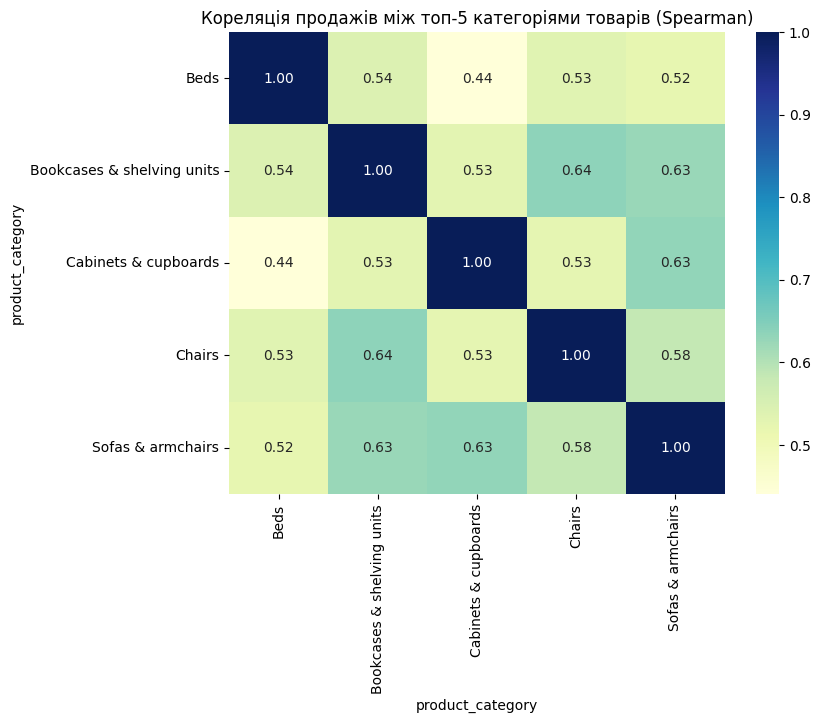

In [ ]:
# візуалізую за допомого теплової карти

# Кореляція Спірмена
corr_matrix_by_category = sale_by_date_by_category.corr(method='spearman')

# Теплова карта
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_by_category, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Кореляція продажів між топ-5 категоріями товарів (Spearman)")
plt.show()

In [ ]:
# кореляція між Bookcases & shelving units і Chairs
print(f"Test statistic spearman and p-value Bookcases & shelving units and Chairs:\n {spearmanr(sale_by_date_by_category['Bookcases & shelving units'], sale_by_date_by_category['Chairs'])}")
spearman_corr_category = sale_by_date_by_category['Bookcases & shelving units'].corr(sale_by_date_by_category['Chairs'], method="spearman")
print(f"Spearman Correlation: {spearman_corr_category}")

# кореляція між Bookcases & shelving units і Sofas & armchairs
print(f"\nTest statistic spearman and p-value Bookcases & shelving units and Sofas & armchairs:\n {spearmanr(sale_by_date_by_category['Bookcases & shelving units'], sale_by_date_by_category['Sofas & armchairs'])}")
spearman_corr_category = sale_by_date_by_category['Bookcases & shelving units'].corr(sale_by_date_by_category['Sofas & armchairs'], method="spearman")
print(f"Spearman Correlation: {spearman_corr_category}")

# кореляція між Cabinets & cupboards і Sofas & armchairs
print(f"\nTest statistic spearman and p-value Cabinets & cupboards and Sofas & armchairs:\n {spearmanr(sale_by_date_by_category['Cabinets & cupboards'], sale_by_date_by_category['Sofas & armchairs'])}")
spearman_corr_category = sale_by_date_by_category['Cabinets & cupboards'].corr(sale_by_date_by_category['Sofas & armchairs'], method="spearman")
print(f"Spearman Correlation: {spearman_corr_category}")

# кореляція між Chairs і Sofas & armchairs
print(f"\nTest statistic spearman and p-value Chairs and Sofas & armchairs:\n {spearmanr(sale_by_date_by_category['Chairs'], sale_by_date_by_category['Sofas & armchairs'])}")
spearman_corr_category = sale_by_date_by_category['Chairs'].corr(sale_by_date_by_category['Sofas & armchairs'], method="spearman")
print(f"Spearman Correlation: {spearman_corr_category}")




Test statistic spearman and p-value Bookcases & shelving units and Chairs:
 SignificanceResult(statistic=np.float64(0.6367510830897116), pvalue=np.float64(2.5854375788053062e-11))
Spearman Correlation: 0.6367510830897116

Test statistic spearman and p-value Bookcases & shelving units and Sofas & armchairs:
 SignificanceResult(statistic=np.float64(0.6256031841076398), pvalue=np.float64(7.188990897333014e-11))
Spearman Correlation: 0.6256031841076398

Test statistic spearman and p-value Cabinets & cupboards and Sofas & armchairs:
 SignificanceResult(statistic=np.float64(0.6312035504209081), pvalue=np.float64(4.322908272307604e-11))
Spearman Correlation: 0.6312035504209081

Test statistic spearman and p-value Chairs and Sofas & armchairs:
 SignificanceResult(statistic=np.float64(0.5833186573209821), pvalue=np.float64(2.4628200563808208e-09))
Spearman Correlation: 0.5833186573209821


Посилання на дашборд в Tableau

[Sales and session analysis](https://public.tableau.com/app/profile/tetiana.shlemko/viz/Salesandsession/Salesandsessionanalysis?publish=yes)